<a href="https://colab.research.google.com/github/SamikshaKaushik-developer/IIT/blob/main/Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Data Preparation and Normalization

We initialize the dataset for Hours Studied vs. Exam Scores. To ensure the Gradient Descent algorithm is stable and converges quickly, we normalize the hours_studied feature using Z-score normalization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset
hours_studied = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
exam_scores = np.array([45, 55, 60, 62, 75, 78, 85, 90, 92, 98])

# Normalization
mu = np.mean(hours_studied)
std = np.std(hours_studied)
x_norm = (hours_studied - mu) / std
y = exam_scores

# Initialize Parameters
m, c = 0.0, 0.0
learning_rate = 0.01
iterations = 1000
cost_history = []
n = len(y)

# Gradient Descent Loop
for i in range(iterations):
    # 1. Predict
    predictions = m * x_norm + c

    # 2. Compute Errors and Cost (MSE)
    error = predictions - y
    cost = (1 / (2 * n)) * np.sum(error**2)
    cost_history.append(cost)

    # 3. Calculate Gradients
    grad_m = (1 / n) * np.sum(error * x_norm)
    grad_c = (1 / n) * np.sum(error)

    # 4. Update Parameters
    m -= learning_rate * grad_m
    c -= learning_rate * grad_c

print(f"Optimization Complete.")
print(f"Final m (Slope): {m:.4f}")
print(f"Final c (I2. Visualizing the Best-Fit Line and Learning Curvetercept): {c:.4f}")

Optimization Complete.
Final m (Slope): 16.6759
Final c (Intercept): 73.9968


# 2. Visualizing the Best-Fit Line and Learning Curve

Below we visualize the relationship between hours studied and exam scores. The red line represents the model's "learned" understanding of the data. We also plot the Learning Curve to prove that the Mean Squared Error (MSE) decreases as iterations increase.

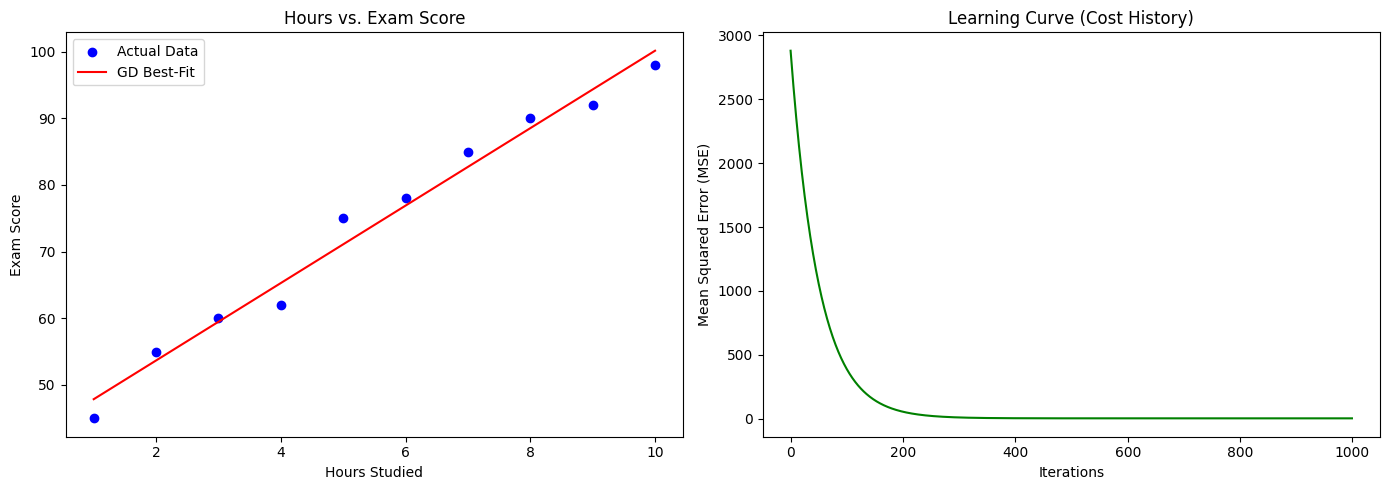

In [2]:
# Create Subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Best-Fit Line
ax1.scatter(hours_studied, exam_scores, color='blue', label='Actual Data')
# Note: We use x_norm for the prediction because the model was trained on normalized data
ax1.plot(hours_studied, m * x_norm + c, color='red', label='GD Best-Fit')
ax1.set_xlabel('Hours Studied')
ax1.set_ylabel('Exam Score')
ax1.set_title('Hours vs. Exam Score')
ax1.legend()

# Plot 2: Learning Curve
ax2.plot(cost_history, color='green')
ax2.set_xlabel('Iterations')
ax2.set_ylabel('Mean Squared Error (MSE)')
ax2.set_title('Learning Curve (Cost History)')

plt.tight_layout()
plt.show()

# 3. Bonus: Impact of Learning Rates

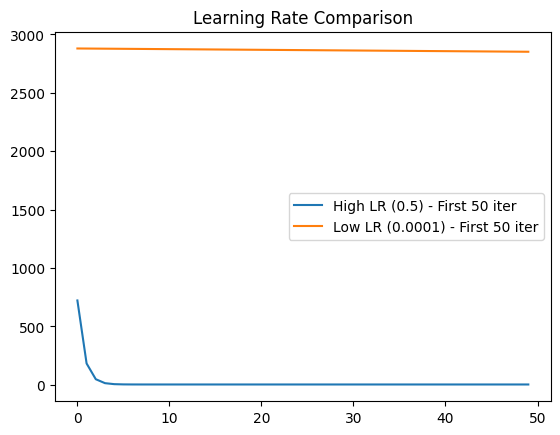

In [3]:
def run_gd(lr):
    m_tmp, c_tmp = 0.0, 0.0
    history = []
    for _ in range(iterations):
        preds = m_tmp * x_norm + c_tmp
        grad_m = (1/n) * np.sum((preds - y) * x_norm)
        grad_c = (1/n) * np.sum(preds - y)
        m_tmp -= lr * grad_m
        c_tmp -= lr * grad_c
        history.append((1/(2*n)) * np.sum((m_tmp * x_norm + c_tmp - y)**2))
    return history

high_lr_history = run_gd(0.5)
low_lr_history = run_gd(0.0001)

plt.plot(high_lr_history[:50], label='High LR (0.5) - First 50 iter')
plt.plot(low_lr_history[:50], label='Low LR (0.0001) - First 50 iter')
plt.title("Learning Rate Comparison")
plt.legend()
plt.show()

# Final Explanation

1. High Learning Rate (0.5): The model may
converge very quickly, but if the rate is too high, it can overshoot the minimum and cause the cost to explode (divergence).
2. Low Learning Rate (0.0001): The model is "too cautious." It takes tiny steps, and after 1000 iterations, it still hasn't reached the optimal $m$ and $c$ values.
3. Optimal Learning Rate (0.01): Strikes the perfect balance between speed and stability.


